# Import essential libraries

In [6]:
import pandas as pd              
import numpy as np               
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Import dataset and info of it

In [7]:
data = pd.read_csv('odi.csv')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4744 entries, 0 to 4743
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Match Format           4744 non-null   object
 1   Team1 Name             4744 non-null   object
 2   Team2 Name             4744 non-null   object
 3   Match Venue (Stadium)  4744 non-null   object
 4   Match Venue (Country)  4744 non-null   object
 5   Toss Winner            4744 non-null   object
 6   Toss Winner Choice     4744 non-null   object
 7   Match Winner           4744 non-null   object
 8   Team1 Runs Scored      4744 non-null   int64 
 9   Team1 Wickets Fell     4744 non-null   int64 
 10  Team2 Runs Scored      4744 non-null   int64 
 11  Team2 Wickets Fell     4744 non-null   int64 
dtypes: int64(4), object(8)
memory usage: 296.6+ KB


# Check whether how many counts of each components in 'Match Format'

In [10]:
choice_counts = data['Match Format'].value_counts()
choice_counts

Match Format
ODI    4744
Name: count, dtype: int64

# Encode table data (teams names)

In [12]:
team_related_cols = ['Team1 Name', 'Team2 Name', 'Toss Winner', 'Match Winner', 'Match Venue (Country)']

# Combine all unique team names + countries (so mapping stays consistent)
unique_teams = pd.unique(data[team_related_cols].values.ravel())
print("✅ Unique team/country names found:\n", unique_teams)

# Fit a single encoder for all team/country names
team_encoder = LabelEncoder()
team_encoder.fit(unique_teams)

# Apply encoding (starting from 1 instead of 0)
for col in team_related_cols:
    data[col] = team_encoder.transform(data[col]) 

# Team name (and country) mapping
team_mapping = {team: code for team, code in zip(team_encoder.classes_, team_encoder.transform(team_encoder.classes_))}
print("\n🏏 Team/Country → Encoded Number Mapping:")
for team, code in team_mapping.items():
    print(f"{team} → {code}")

✅ Unique team/country names found:
 ['Australia' 'New Zealand' 'Sri Lanka' 'England' 'India' 'West Indies'
 'United Arab Emirates' 'Bangladesh' 'Pakistan' '0' 'East Africa' 'Canada'
 'Zimbabwe' 'South Africa' 'U.A.E.' 'Netherlands' 'Kenya' 'Singapore'
 'Scotland' 'Ireland' 'Morocco' 'Namibia' 'Hong Kong' 'U.S.A.'
 'ICC World XI' 'Asia XI' 'Africa XI' 'Bermuda' 'Malaysia' 'Afghanistan'
 'P.N.G.' 'Papua New Guinea' 'Nepal' 'Oman' 'United States of America'
 'Qatar' 'Jersey']

🏏 Team/Country → Encoded Number Mapping:
0 → 0
Afghanistan → 1
Africa XI → 2
Asia XI → 3
Australia → 4
Bangladesh → 5
Bermuda → 6
Canada → 7
East Africa → 8
England → 9
Hong Kong → 10
ICC World XI → 11
India → 12
Ireland → 13
Jersey → 14
Kenya → 15
Malaysia → 16
Morocco → 17
Namibia → 18
Nepal → 19
Netherlands → 20
New Zealand → 21
Oman → 22
P.N.G. → 23
Pakistan → 24
Papua New Guinea → 25
Qatar → 26
Scotland → 27
Singapore → 28
South Africa → 29
Sri Lanka → 30
U.A.E. → 31
U.S.A. → 32
United Arab Emirates → 33
United

# Encode table data (ground)

In [13]:
ground_encoder = LabelEncoder()

data['Match Venue (Stadium)'] = ground_encoder.fit_transform(data['Match Venue (Stadium)'])

# Ground mapping
ground_mapping = {ground: code for ground, code in zip(ground_encoder.classes_, ground_encoder.transform(ground_encoder.classes_))}
print("\n Ground Encoded Number Mapping:")
for ground, code in ground_mapping.items():
    print(f"{ground} → {code}")


 Ground Encoded Number Mapping:
AMI Stadium → 0
Adelaide Oval → 1
Affies Park → 2
Aga Khan Sports Club Ground → 3
Al Amerat Cricket Ground Oman Cricket (Ministry Turf 1) → 4
Al Amerat Cricket Ground Oman Cricket (Ministry Turf 2) → 5
Albion Sports Complex → 6
Amini Park → 7
Andhra Cricket Association-Visakhapatnam District Cricket Association Stadium → 8
Antigua Recreation Ground → 9
Arbab Niaz Stadium → 10
Arnos Vale Ground → 11
Arun Jaitley Stadium → 12
Asgiriya Stadium → 13
Ayub National Stadium → 14
Bangabandhu National Stadium → 15
Barabati Stadium → 16
Barkatullah Khan Stadium → 17
Barsapara Cricket Stadium → 18
Basin Reserve → 19
Bay Oval → 20
Bayuemas Oval → 21
Beausejour Stadium → 22
Bellerive Oval → 23
Berri Oval → 24
Bert Sutcliffe Oval → 25
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium → 26
Boland Bank Park → 27
Boland Park → 28
Bourda → 29
Brabourne Stadium → 30
Bready Cricket Club → 31
Brian Lara Stadium → 32
Brisbane Cricket Ground → 33
Buffalo Park → 34


# Encode table data (match format)

In [15]:
format_mapping = {
    'ODI': 1,
}

data['Match Format'] = data['Match Format'].map(format_mapping)

# Encode table data (toss winner choice)

In [16]:
toss_choice_mapping = {
    'bat': 1,
    'bowl': 2
}

data['Toss Winner Choice'] = data['Toss Winner Choice'].map(toss_choice_mapping)

# Make correation to the identify proper columns

Match Winner             1.000000
Team2 Name               0.406287
Toss Winner              0.390399
Team1 Name               0.383854
Match Venue (Country)    0.291248
Team2 Runs Scored        0.111749
Team2 Wickets Fell       0.086846
Team1 Wickets Fell       0.043605
Team1 Runs Scored        0.042749
Toss Winner Choice       0.025469
Match Venue (Stadium)   -0.029559
Match Format                  NaN
Name: Match Winner, dtype: float64


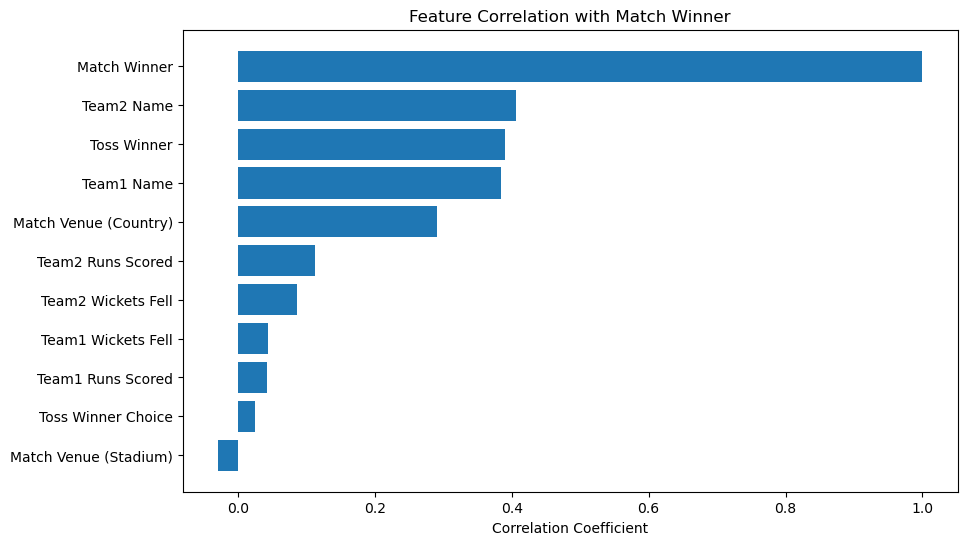

In [18]:
import matplotlib.pyplot as plt

correlation = data.corr(numeric_only=True)['Match Winner'].sort_values(ascending=False)
print(correlation)

# Plot using matplotlib only
plt.figure(figsize=(10,6))
plt.barh(correlation.index, correlation.values)
plt.title("Feature Correlation with Match Winner")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis() 
plt.show()

# Drop low-correlation columns

In [19]:
columns_to_drop = [
    'Match Venue (Stadium)',
    'Toss Winner Choice',
]

data = data.drop(columns=columns_to_drop, axis=1)

# Check the remaining columns
data.columns

Index(['Match Format', 'Team1 Name', 'Team2 Name', 'Match Venue (Country)',
       'Toss Winner', 'Match Winner', 'Team1 Runs Scored',
       'Team1 Wickets Fell', 'Team2 Runs Scored', 'Team2 Wickets Fell'],
      dtype='object')

# Separate features (X) and target (y)

In [20]:
X = data.drop(['Match Winner','Match Format'], axis=1)
y = data['Match Winner']

# Train and test dataset

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model dictionary to find the best model

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# train each models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {'Accuracy': acc, 'F1 Score': f1}

# Show comparison
results_df = pd.DataFrame(results).T
results_df.sort_values(by='Accuracy', ascending=False)

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Accuracy,F1 Score
Gradient Boosting,0.907271,0.906594
Random Forest,0.847208,0.840936
Logistic Regression,0.239199,0.178179
SVM,0.228662,0.138713


# Select the best model

In [27]:
gradient_boost_model = models['Gradient Boosting']

# Try example encoded user input

In [28]:
new_match = {
    'Team1 Name': 4,   
    'Team2 Name': 12,  
    'Match Venue (Country)': 4,  
    'Toss Winner': 4   
}

# Convert to DataFrame
new_df = pd.DataFrame([new_match])

# Get the mean values for runs scored, wickets fell for each teams using stats by handle NaN values using Global averages
team1 = new_match['Team1 Name']
team2 = new_match['Team2 Name']


# --- Filter head-to-head matches ---
head_to_head = data[
    ((data['Team1 Name'] == team1) & (data['Team2 Name'] == team2)) |
    ((data['Team1 Name'] == team2) & (data['Team2 Name'] == team1))
].copy()

# Fallback if no direct matches found
if head_to_head.empty:
    print("⚠️ No direct head-to-head matches found. Using global averages.")
    head_to_head = data.copy()


# --- Compute averages for both teams ---
def get_mean_stat(data, t1, t2):
    """Compute mean runs and wickets based on historical data."""
    t1_as_team1 = data[(data['Team1 Name'] == t1) & (data['Team2 Name'] == t2)]
    t1_as_team2 = data[(data['Team1 Name'] == t2) & (data['Team2 Name'] == t1)]

    # Averages for Team 1
    t1_runs = pd.concat([t1_as_team1['Team1 Runs Scored'], t1_as_team2['Team2 Runs Scored']], ignore_index=True)
    t1_wickets = pd.concat([t1_as_team1['Team1 Wickets Fell'], t1_as_team2['Team2 Wickets Fell']], ignore_index=True)

    # Averages for Team 2
    t2_runs = pd.concat([t1_as_team1['Team2 Runs Scored'], t1_as_team2['Team1 Runs Scored']], ignore_index=True)
    t2_wickets = pd.concat([t1_as_team1['Team2 Wickets Fell'], t1_as_team2['Team1 Wickets Fell']], ignore_index=True)

    return (
        round(t1_runs.mean(), 2) if not t1_runs.empty else np.nan,
        round(t1_wickets.mean(), 2) if not t1_wickets.empty else np.nan,
        round(t2_runs.mean(), 2) if not t2_runs.empty else np.nan,
        round(t2_wickets.mean(), 2) if not t2_wickets.empty else np.nan
    )


# --- Calculate mean stats ---
t1_runs, t1_wickets, t2_runs, t2_wickets = get_mean_stat(head_to_head, team1, team2)

# Fill the calculated stats
new_df['Team1 Runs Scored'] = t1_runs
new_df['Team1 Wickets Fell'] = t1_wickets
new_df['Team2 Runs Scored'] = t2_runs
new_df['Team2 Wickets Fell'] = t2_wickets


# Columns that need to be filled
missing_features = ['Team1 Runs Scored', 'Team1 Wickets Fell',
                    'Team2 Runs Scored', 'Team2 Wickets Fell']

# Handle NaN (use global averages)
for feature in missing_features:
    if pd.isna(new_df.loc[0, feature]):
        new_df.loc[0, feature] = data[feature].mean()


print("\n📊 Head-to-Head or Global Averages Used:")
print(f"Team1 (encoded {team1}) Runs: {t1_runs}, Wickets: {t1_wickets}")
print(f"Team2 (encoded {team2}) Runs: {t2_runs}, Wickets: {t2_wickets}")


# Ensure same feature order as training
new_df = new_df[X.columns]

print("\n✅ Final Input for Prediction:")
print(new_df)


📊 Head-to-Head or Global Averages Used:
Team1 (encoded 4) Runs: 241.65, Wickets: 6.71
Team2 (encoded 12) Runs: 227.73, Wickets: 7.26

✅ Final Input for Prediction:
   Team1 Name  Team2 Name  Match Venue (Country)  Toss Winner  \
0           4          12                      4            4   

   Team1 Runs Scored  Team1 Wickets Fell  Team2 Runs Scored  \
0             241.65                6.71             227.73   

   Team2 Wickets Fell  
0                7.26  


# Prediction Probabilities

In [ ]:
try:
    probabilities = gradient_boost_model.predict_proba(new_df)[0]
    classes = gradient_boost_model.classes_

    # Initialize default values
    team1_prob = team2_prob = tie_prob = 0.0

    for cls, prob in zip(classes, probabilities):
        if cls == team1:
            team1_prob = prob * 100
        elif cls == team2:
            team2_prob = prob * 100
        elif cls == 0:
            tie_prob = prob * 100  # 0 means tie/no result

    
    # Normalize (if tie/no result small, adjust for 100%)
    total = team1_prob + team2_prob + tie_prob
    if total > 0:
        team1_prob = round((team1_prob / total) * 100, 2)
        team2_prob = round((team2_prob / total) * 100, 2)
        tie_prob = round((tie_prob / total) * 100, 2)

    print("\n🏏 Predicted Winning Probabilities:")
    print(f"Team1 (Encoded {team1}) Winning Chance: {team1_prob}%")
    print(f"Team2 (Encoded {team2}) Winning Chance: {team2_prob}%")
    print(f"Tie/No Result Chance: {tie_prob}%")

except Exception as e:
    print(f"\n❌ Prediction failed: {e}")